# Laboratorio 1. Series de Tiempo

## Modelado de las series de fronteras

Fernando Rueda - 23748

Fernando Hernández - 23645

Este cuaderno cubre el modelado ARIMA (incisos 4f y 4g) para las tres series de fronteras: La
Aurora, Valle Nuevo y San Cristóbal. Parte del diagnóstico del análisis preliminar
(`analisis-series.ipynb`): las tres series se modelan en logaritmo, con d = 1 confirmado por la
prueba de Dickey-Fuller aumentada y componente estacional de período 12. Para cada serie
ajustamos varios modelos SARIMA, los comparamos por AIC y BIC, analizamos los residuos del
mejor y contrastamos nuestra propuesta manual contra auto_arima de pmdarima.

Todo el ajuste se hace sobre el conjunto de entrenamiento (enero 2009 a marzo 2021). El
conjunto de prueba no se toca en este cuaderno; se usa más adelante para evaluar pronósticos.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pmdarima as pm
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")  # los SARIMA de la rejilla avisan sobre convergencia sin afectar el resultado

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIGURAS = RAIZ / "reports" / "figuras"
FIGURAS.mkdir(parents=True, exist_ok=True)

PALETA = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
AZUL, NARANJA, AQUA, AMARILLO, MAGENTA = PALETA
GRIS = "#8a8a85"

plt.rcParams.update({
    "figure.figsize": (11, 4.2),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e4e4e0",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "axes.titlesize": 12,
    "axes.titleweight": "semibold",
    "font.size": 10,
    "legend.frameon": False,
})

def guardar(nombre):
    plt.tight_layout()
    plt.savefig(FIGURAS / f"{nombre}.png", bbox_inches="tight", facecolor="white")

pd.set_option("display.width", 160)

/Users/ferahmz/Documents/uvg/octavo/Data Science/Laboratorio-1-Series-de-Tiempo/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
train = pd.read_csv(RAIZ / "data" / "processed" / "series_train.csv", parse_dates=["fecha"]).set_index("fecha").asfreq("MS")

FRONTERAS = ["frontera: La Aurora", "frontera: Valle Nuevo", "frontera: San Cristóbal"]
logs = {nombre: np.log(train[nombre]) for nombre in FRONTERAS}
print(f"Entrenamiento: {train.index.min():%Y-%m} a {train.index.max():%Y-%m}, {len(train)} meses")

Entrenamiento: 2009-01 a 2021-03, 147 meses


## 1. Metodología

**Candidatos.** El análisis preliminar dejó como punto de partida el SARIMA(0,1,1)(0,1,1)₁₂
sobre el log, con la parte regular sugerida por el rezago 1 negativo de los correlogramas y la
estacional por el rezago 12. Alrededor de ese candidato ajustamos una rejilla de nueve modelos:
variantes AR contra MA en la parte regular (p, q en {0, 1, 2}), variantes AR contra MA en la
estacional (P, Q en {0, 1}), y dos variantes con D = 0 para las fronteras donde la diferencia
estacional quedó como opcional (La Aurora y Valle Nuevo).

**Comparación.** AIC y BIC comparan el ajuste penalizando parámetros. Solo son comparables
entre modelos con la misma diferenciación, porque cambiar d o D cambia la serie sobre la que se
calcula la verosimilitud; los modelos con D = 0 se evalúan aparte por sus residuos. El segundo
criterio es la prueba de Ljung-Box sobre los residuos: un buen modelo deja residuos sin
autocorrelación (p > 0.05 significa residuos compatibles con ruido blanco).

**Advertencia sobre el tramo pandémico.** Los últimos doce meses del entrenamiento son el
colapso de 2020. Ningún SARIMA con estacionalidad fija puede seguir una caída del 99%, así que
los residuos de 2020 van a ser enormes en todas las especificaciones. Eso no distingue entre
candidatos (castiga a todos por igual) pero sí contamina las pruebas de normalidad y, como se
verá en La Aurora, puede dejar autocorrelación residual que ningún orden extra elimina.

In [3]:
CANDIDATOS = [
    ((0, 1, 1), (0, 1, 1, 12)),
    ((1, 1, 0), (0, 1, 1, 12)),
    ((1, 1, 1), (0, 1, 1, 12)),
    ((0, 1, 2), (0, 1, 1, 12)),
    ((0, 1, 1), (1, 1, 0, 12)),
    ((0, 1, 1), (0, 1, 0, 12)),
    ((0, 1, 2), (0, 1, 0, 12)),
    ((0, 1, 1), (1, 0, 1, 12)),   # D = 0
    ((1, 1, 1), (1, 0, 1, 12)),   # D = 0
]


def etiqueta(orden, sorden):
    return f"SARIMA{orden}x{sorden[:3]}12"


def ajustar_rejilla(y):
    """Ajusta los candidatos y devuelve la tabla de comparación y los resultados."""
    filas, ajustes = [], {}
    for orden, sorden in CANDIDATOS:
        r = SARIMAX(y, order=orden, seasonal_order=sorden).fit(disp=False)
        resid = r.resid[r.loglikelihood_burn:]
        filas.append({
            "modelo": etiqueta(orden, sorden),
            "D": sorden[1],
            "AIC": round(r.aic, 1),
            "BIC": round(r.bic, 1),
            "Ljung-Box p (12)": round(acorr_ljungbox(resid, lags=[12]).iloc[0, 1], 3),
            "Ljung-Box p (24)": round(acorr_ljungbox(resid, lags=[24]).iloc[0, 1], 3),
        })
        ajustes[etiqueta(orden, sorden)] = r
    tabla = pd.DataFrame(filas).set_index("modelo").sort_values(["D", "AIC"], ascending=[False, True])
    return tabla, ajustes


def diagnostico_residuos(resultado, titulo, nombre_figura):
    fig = resultado.plot_diagnostics(figsize=(11, 7), lags=24)
    fig.suptitle(titulo, y=1.0)
    guardar(nombre_figura)
    plt.show()

## 2. La Aurora

### 2.1 Rejilla de modelos SARIMA

In [4]:
tabla_aurora, ajustes_aurora = ajustar_rejilla(logs["frontera: La Aurora"])
tabla_aurora

,D,AIC,BIC,Ljung-Box p (12),Ljung-Box p (24)
modelo,,,,,
"SARIMA(0, 1, 1)x(1, 1, 0)12",1,194.8,203.5,0.013,0.373
"SARIMA(0, 1, 1)x(0, 1, 1)12",1,195.5,204.2,0.014,0.381
"SARIMA(1, 1, 0)x(0, 1, 1)12",1,195.6,204.3,0.014,0.385
"SARIMA(1, 1, 1)x(0, 1, 1)12",1,197.2,208.8,0.014,0.384
"SARIMA(0, 1, 2)x(0, 1, 1)12",1,197.2,208.7,0.013,0.368
"SARIMA(0, 1, 1)x(0, 1, 0)12",1,199.1,204.9,0.012,0.339
"SARIMA(0, 1, 2)x(0, 1, 0)12",1,200.8,209.5,0.011,0.330
"SARIMA(0, 1, 1)x(1, 0, 1)12",0,202.6,214.5,0.028,0.490
"SARIMA(1, 1, 1)x(1, 0, 1)12",0,204.0,218.9,0.030,0.503


Entre los modelos con D = 1, que son comparables entre sí, el mejor AIC es el
**SARIMA(0,1,1)(1,1,0)₁₂** con 194.8, seguido a menos de un punto por el airline
SARIMA(0,1,1)(0,1,1)₁₂ (195.5) y el SARIMA(1,1,0)(0,1,1)₁₂ (195.6). Diferencias de AIC menores
a 2 no son concluyentes, así que los tres son estadísticamente equivalentes en ajuste; el BIC
ordena igual. Agregar órdenes (p o q en 2, o ambos términos estacionales) solo empeora el
criterio: la penalización por parámetros no se paga.

Los dos modelos con D = 0, la ruta alternativa que dejó abierta el análisis preliminar, no la
justifican: sus residuos no son mejores (Ljung-Box en 12 de 0.028 contra 0.013) y trasladan la
estacionalidad a un AR estacional cerca de la no invertibilidad. Nos quedamos con D = 1.

La columna de Ljung-Box en el rezago 12 merece atención: **todos** los candidatos con D = 1
quedan entre 0.011 y 0.014, debajo de 0.05. Ningún orden adicional lo arregla (probamos también
(0,1,1)(1,1,1)₁₂ y (1,1,1)(1,1,1)₁₂ fuera de la rejilla, con LB12 de 0.014). La causa se ve en
el diagnóstico de abajo.

### 2.2 Residuos del modelo elegido

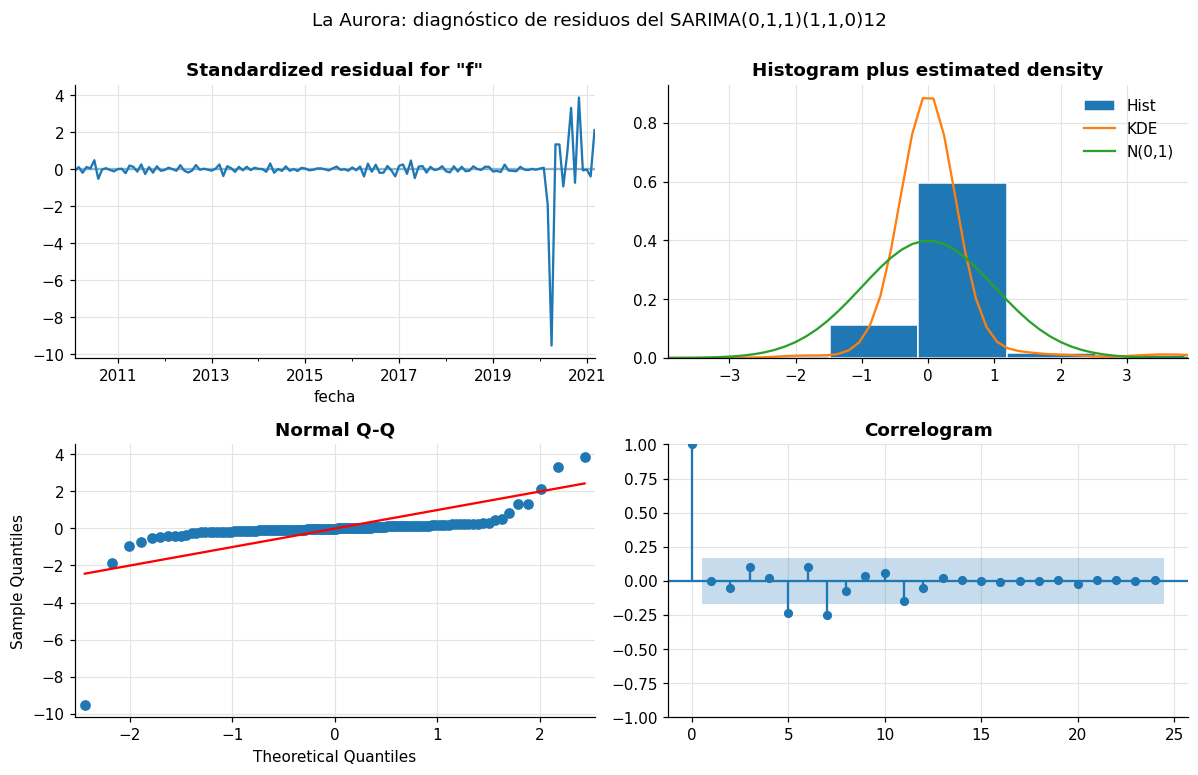

Los tres residuos más grandes (en log):
fecha
2020-04-01    4.60
2020-11-01    1.87
2020-09-01    1.60


In [5]:
mejor_aurora = ajustes_aurora["SARIMA(0, 1, 1)x(1, 1, 0)12"]
diagnostico_residuos(mejor_aurora, "La Aurora: diagnóstico de residuos del SARIMA(0,1,1)(1,1,0)12",
                     "modelado-aurora-residuos")
resid = mejor_aurora.resid[mejor_aurora.loglikelihood_burn:]
print("Los tres residuos más grandes (en log):")
print(resid.abs().nlargest(3).round(2).to_string())

El residuo dominante es **abril de 2020, con 4.6 desviaciones en escala log**: el mes del
cierre total del aeropuerto, donde la serie cayó a 484 visitantes. Le siguen otros meses de
2020. Ese bloque de residuos gigantes y correlacionados entre sí es lo que dispara el Ljung-Box
en el rezago 12 y engorda las colas del QQ-plot; fuera del tramo pandémico los residuos se ven
centrados, sin estructura y con el correlograma limpio. La autocorrelación residual es un
artefacto del cambio de régimen, no de una dinámica que el modelo deje sin capturar, así que la
aceptamos documentada en lugar de inflar el modelo con órdenes que no significan nada.

**Elegido para La Aurora: SARIMA(0,1,1)(1,1,0)₁₂ sobre el log.** Interpretación: tras quitar
tendencia (d = 1) y estacionalidad (D = 1), cada mes se corrige con el error del mes anterior
(término MA regular) y con lo que pasó el mismo mes del año pasado (término AR estacional).

### 2.3 Contraste con auto_arima

In [6]:
auto_aurora = pm.auto_arima(logs["frontera: La Aurora"], seasonal=True, m=12,
                            stepwise=True, suppress_warnings=True, error_action="ignore")
print(f"Propuesta de auto_arima: ARIMA{auto_aurora.order}x{auto_aurora.seasonal_order} | AIC {auto_aurora.aic():.1f}")
auto_aurora.summary().tables[1]

Propuesta de auto_arima: ARIMA(3, 0, 2)x(1, 0, 1, 12) | AIC 186.0


,coef,std err,z,P>|z|,[0.025,0.975]
intercept,0.1916,1.936,0.099,0.921,-3.604,3.987
ar.L1,-0.5841,0.118,-4.960,0.000,-0.815,-0.353
ar.L2,0.6412,0.100,6.405,0.000,0.445,0.837
ar.L3,0.4767,0.146,3.257,0.001,0.190,0.764
ma.L1,1.7403,0.093,18.774,0.000,1.559,1.922
ma.L2,0.9042,0.111,8.116,0.000,0.686,1.123
ar.S.L12,0.9633,0.370,2.606,0.009,0.239,1.688
ma.S.L12,-0.8634,0.855,-1.010,0.312,-2.538,0.811
sigma2,0.1746,0.027,6.490,0.000,0.122,0.227


auto_arima propone un **ARIMA(3,0,2)(1,0,1)₁₂ sin ninguna diferenciación**, con AIC 186.0.
¿Tiene sentido? No para nuestro uso, por tres razones. Primera: su AIC no es comparable con los
de la rejilla, porque con d = 0 la verosimilitud se calcula sobre otra serie; el número más
bajo no significa mejor modelo. Segunda: auto_arima decide d con la prueba KPSS, y en el
análisis preliminar vimos que el KPSS no rechaza la estacionariedad del nivel justamente porque
el colapso de 2020 anula once años de tendencia; el ADF, que sí mira la raíz unitaria, dice lo
contrario. Tercera: la tabla de coeficientes muestra dónde escondió la tendencia: el AR
estacional queda en 0.963 con un intervalo de confianza que incluye 1, es decir, imita la
diferencia estacional que se negó a hacer, y la parte MA(2) regular queda al borde de la no
invertibilidad (coeficientes 1.74 y 0.90). El modelo compensa con parámetros extremos lo que
una diferenciación resolvía. Mantenemos nuestra propuesta manual.

## 3. Valle Nuevo

### 3.1 Rejilla de modelos SARIMA

In [7]:
tabla_vnuevo, ajustes_vnuevo = ajustar_rejilla(logs["frontera: Valle Nuevo"])
tabla_vnuevo

,D,AIC,BIC,Ljung-Box p (12),Ljung-Box p (24)
modelo,,,,,
"SARIMA(0, 1, 1)x(1, 1, 0)12",1,323.2,331.9,0.171,0.848
"SARIMA(0, 1, 1)x(0, 1, 1)12",1,323.7,332.4,0.133,0.807
"SARIMA(1, 1, 0)x(0, 1, 1)12",1,324.6,333.2,0.076,0.698
"SARIMA(1, 1, 1)x(0, 1, 1)12",1,325.7,337.3,0.133,0.807
"SARIMA(0, 1, 2)x(0, 1, 1)12",1,325.7,337.3,0.133,0.807
"SARIMA(0, 1, 1)x(0, 1, 0)12",1,328.6,334.3,0.115,0.762
"SARIMA(0, 1, 2)x(0, 1, 0)12",1,330.6,339.2,0.115,0.762
"SARIMA(0, 1, 1)x(1, 0, 1)12",0,333.2,345.1,0.064,0.662
"SARIMA(1, 1, 1)x(1, 0, 1)12",0,335.2,350.1,0.066,0.669


El orden se repite: gana el **SARIMA(0,1,1)(1,1,0)₁₂** con AIC 323.2, empatado en la práctica
con el airline (323.7). La diferencia con La Aurora está en los residuos: aquí los Ljung-Box
pasan con holgura (0.171 en el rezago 12 y 0.848 en el 24 para el mejor modelo). Valle Nuevo
cayó en 2020 igual que La Aurora, pero su caída fue un descenso sostenido de varios meses en
lugar de un desplome de un solo mes, y eso el término MA lo absorbe mejor.

Las variantes con D = 0 vuelven a perder (AIC aparte, sus Ljung-Box son peores: 0.064 contra
0.171) y con ellas la ruta alternativa que el análisis preliminar dejó abierta para esta serie:
la diferencia estacional sí aporta.

### 3.2 Residuos del modelo elegido

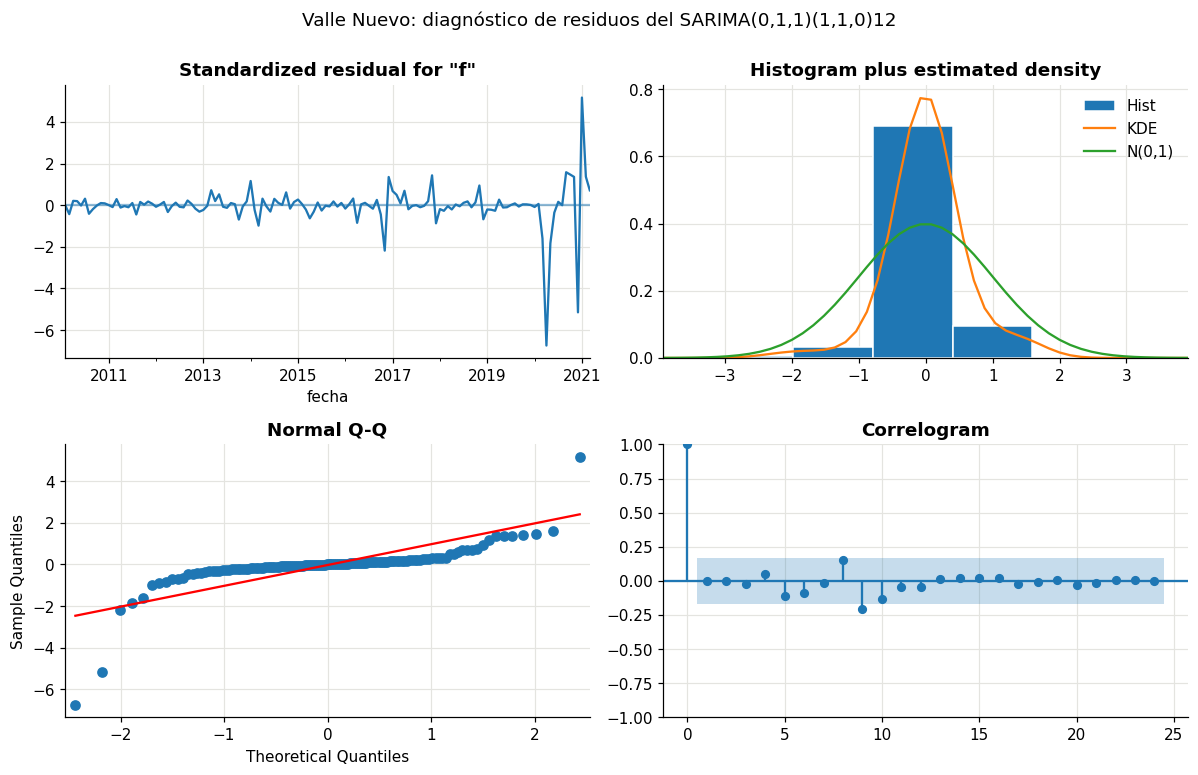

Los tres residuos más grandes (en log):
fecha
2020-04-01    5.28
2021-01-01    4.05
2020-12-01    4.03


In [8]:
mejor_vnuevo = ajustes_vnuevo["SARIMA(0, 1, 1)x(1, 1, 0)12"]
diagnostico_residuos(mejor_vnuevo, "Valle Nuevo: diagnóstico de residuos del SARIMA(0,1,1)(1,1,0)12",
                     "modelado-vnuevo-residuos")
resid = mejor_vnuevo.resid[mejor_vnuevo.loglikelihood_burn:]
print("Los tres residuos más grandes (en log):")
print(resid.abs().nlargest(3).round(2).to_string())

El correlograma de los residuos está limpio en todos los rezagos y el Ljung-Box lo confirma. El
QQ-plot vuelve a mostrar colas pesadas por el bloque pandémico (abril y diciembre 2020, enero
2021, con residuos de 4 a 5.3 en log: la serie pasó de 111 mil a 80 visitantes). Igual que en
La Aurora, es el cambio de régimen y no una falla de especificación.

**Elegido para Valle Nuevo: SARIMA(0,1,1)(1,1,0)₁₂ sobre el log**, el mismo del aeropuerto,
con la ventaja de que aquí los residuos pasan todas las pruebas de autocorrelación.

### 3.3 Contraste con auto_arima

In [9]:
auto_vnuevo = pm.auto_arima(logs["frontera: Valle Nuevo"], seasonal=True, m=12,
                            stepwise=True, suppress_warnings=True, error_action="ignore")
print(f"Propuesta de auto_arima: ARIMA{auto_vnuevo.order}x{auto_vnuevo.seasonal_order} | AIC {auto_vnuevo.aic():.1f}")

Propuesta de auto_arima: ARIMA(1, 0, 1)x(0, 0, 0, 12) | AIC 330.2


Aquí la propuesta automática es directamente insostenible: un **ARIMA(1,0,1) sin diferenciación
y sin ningún componente estacional**. Un modelo sin parte estacional para una serie cuyo índice
de diciembre es 130 y el de febrero 69 no puede reproducir el patrón anual que domina la serie;
pronosticaría un año plano. Es el mismo mecanismo de La Aurora (el KPSS engañado por el colapso
lleva a d = 0) agravado porque el tramo pandémico también diluye la señal estacional que el
procedimiento stepwise necesita para justificar P o Q. La propuesta se descarta y con ella
queda ilustrado el riesgo de usar auto_arima sin revisar el diagnóstico propio de la serie.

## 4. San Cristóbal

### 4.1 Rejilla de modelos SARIMA

In [10]:
tabla_scristobal, ajustes_scristobal = ajustar_rejilla(logs["frontera: San Cristóbal"])
tabla_scristobal

,D,AIC,BIC,Ljung-Box p (12),Ljung-Box p (24)
modelo,,,,,
"SARIMA(1, 1, 0)x(0, 1, 1)12",1,257.8,266.5,0.048,0.473
"SARIMA(0, 1, 1)x(1, 1, 0)12",1,258.4,267.1,0.047,0.501
"SARIMA(1, 1, 1)x(0, 1, 1)12",1,258.6,270.2,0.098,0.594
"SARIMA(0, 1, 1)x(0, 1, 1)12",1,260.2,268.9,0.037,0.461
"SARIMA(0, 1, 2)x(0, 1, 1)12",1,261.8,273.4,0.042,0.465
"SARIMA(0, 1, 1)x(0, 1, 0)12",1,267.1,272.9,0.029,0.401
"SARIMA(0, 1, 2)x(0, 1, 0)12",1,268.2,276.9,0.052,0.482
"SARIMA(1, 1, 1)x(1, 0, 1)12",0,269.5,284.5,0.060,0.436
"SARIMA(0, 1, 1)x(1, 0, 1)12",0,271.6,283.6,0.030,0.379


San Cristóbal es el único caso donde AIC y residuos apuntan a modelos distintos. El mínimo AIC
es el SARIMA(1,1,0)(0,1,1)₁₂ (257.8), pero su Ljung-Box en el rezago 12 queda al filo (0.048).
A 0.8 puntos de AIC, diferencia irrelevante, el **SARIMA(1,1,1)(0,1,1)₁₂** deja residuos
claramente más limpios (0.098 en el 12, 0.594 en el 24). Preferimos pagar un parámetro más a
cambio de residuos que pasan las pruebas: el AR(1) regular captura la inercia de la serie y el
MA(1) limpia lo que queda.

Nótese que la parte estacional elegida aquí es MA (Q = 1) y no AR como en las otras dos
fronteras, y que los modelos con D = 0 son los peores de la tabla, coherente con el análisis
preliminar: en esta serie la diferencia estacional era obligatoria (el ADF con solo d = 1 daba
p = 0.91).

### 4.2 Residuos del modelo elegido

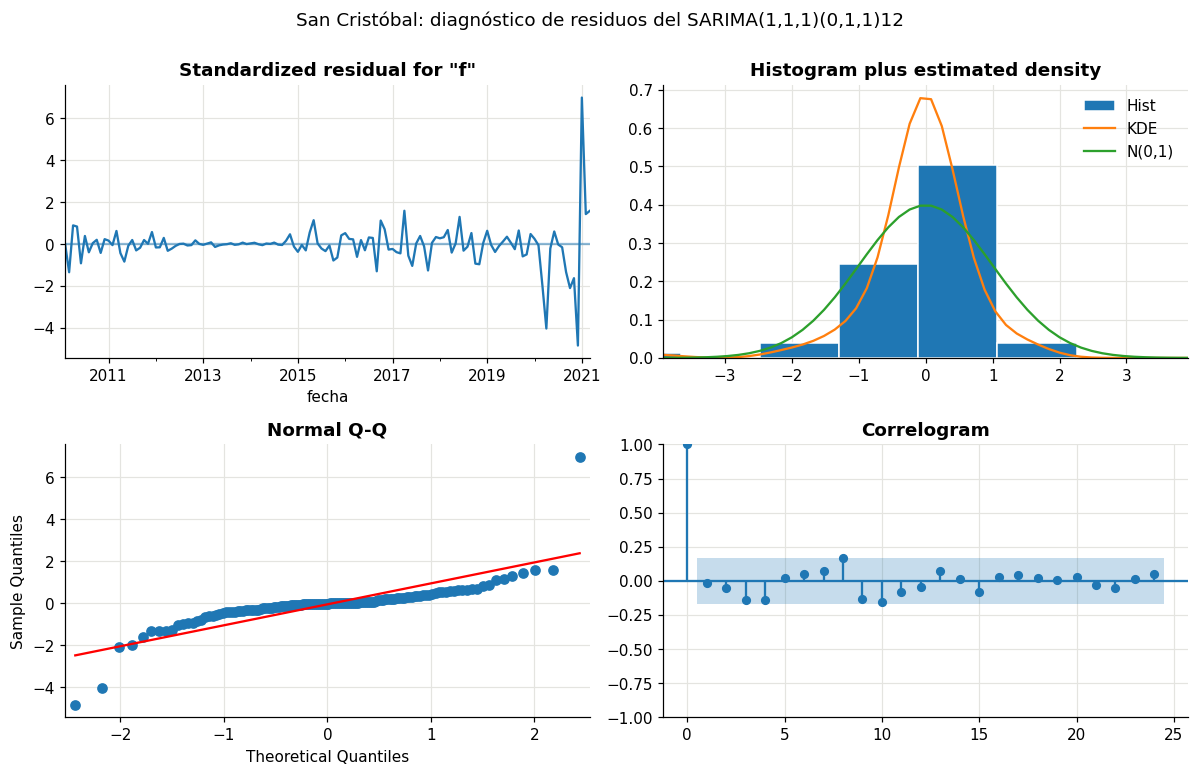

Los tres residuos más grandes (en log):
fecha
2021-01-01    4.27
2020-12-01    2.96
2020-04-01    2.46


In [11]:
mejor_scristobal = ajustes_scristobal["SARIMA(1, 1, 1)x(0, 1, 1)12"]
diagnostico_residuos(mejor_scristobal, "San Cristóbal: diagnóstico de residuos del SARIMA(1,1,1)(0,1,1)12",
                     "modelado-scristobal-residuos")
resid = mejor_scristobal.resid[mejor_scristobal.loglikelihood_burn:]
print("Los tres residuos más grandes (en log):")
print(resid.abs().nlargest(3).round(2).to_string())

Mismo patrón que las demás: correlograma residual limpio, colas pesadas por la pandemia
(diciembre 2020 y enero 2021, la serie tocó 14 visitantes). Fuera de ese bloque el modelo sigue
bien una serie que es la más ruidosa del grupo (el residuo de la descomposición prepandemia era
del 21%).

**Elegido para San Cristóbal: SARIMA(1,1,1)(0,1,1)₁₂ sobre el log.**

### 4.3 Contraste con auto_arima

In [12]:
auto_scristobal = pm.auto_arima(logs["frontera: San Cristóbal"], seasonal=True, m=12,
                                stepwise=True, suppress_warnings=True, error_action="ignore")
print(f"Propuesta de auto_arima: ARIMA{auto_scristobal.order}x{auto_scristobal.seasonal_order} | AIC {auto_scristobal.aic():.1f}")

Propuesta de auto_arima: ARIMA(3, 0, 4)x(2, 0, 0, 12) | AIC 264.3


Tercera vez el mismo defecto: **ARIMA(3,0,4)(2,0,0)₁₂ con d = 0 y D = 0**, ahora además con
nueve parámetros ARMA, el modelo más pesado que ha propuesto para la serie con menos señal por
mes. Para una serie donde la evidencia estadística exige las dos diferenciaciones, una
propuesta sin ninguna no tiene sentido; el exceso de parámetros es la compensación. Se
descarta.

## 5. Resumen del modelado ARIMA de fronteras

| Serie | Modelo elegido | AIC | BIC | Ljung-Box p (12 / 24) |
|---|---|---|---|---|
| La Aurora | SARIMA(0,1,1)(1,1,0)₁₂ en log | 194.8 | 203.5 | 0.013 / 0.373 |
| Valle Nuevo | SARIMA(0,1,1)(1,1,0)₁₂ en log | 323.2 | 331.9 | 0.171 / 0.848 |
| San Cristóbal | SARIMA(1,1,1)(0,1,1)₁₂ en log | 258.6 | 270.2 | 0.098 / 0.594 |

Tres lecturas cierran esta parte.

**La estructura es casi la misma en las tres fronteras.** Diferenciación regular y estacional,
un término regular de corrección y un término estacional. Es la estructura airline con
variantes menores, y confirma que los candidatos leídos de los correlogramas en el análisis
preliminar iban bien encaminados: en ninguna serie la rejilla encontró algo sustancialmente
mejor que el punto de partida.

**Los residuos aprueban con una excepción explicada.** Valle Nuevo y San Cristóbal pasan
Ljung-Box en todos los rezagos. La Aurora no pasa en el 12 con ningún candidato, y el
diagnóstico muestra por qué: el residuo de 4.6 desviaciones de abril 2020, el mes del cierre
del aeropuerto. Es un límite de los datos, no del modelo, y quedará igualmente expuesto en los
algoritmos alternativos.

**auto_arima falló en las tres series y siempre por lo mismo.** Su prueba de raíz unitaria por
defecto (KPSS) lee el colapso pandémico como ausencia de tendencia y concluye d = 0; después
compensa con partes AR al borde de la raíz unitaria (La Aurora), sin estacionalidad (Valle
Nuevo) o sobreparametrizadas (San Cristóbal). Con series que traen un cambio de régimen, la
selección automática necesita supervisión: nuestro diagnóstico manual con ADF más correlogramas
produjo modelos más simples y con mejores residuos.

Sigue: los modelos alternativos (Prophet, Holt-Winters, suavizamiento exponencial y seasonal
naive), el pronóstico sobre el conjunto de prueba y la comparación por MAE y RMSE.